In [2]:
import tensorflow as tf
from tensorflow import keras

In [4]:
(X_train,y_train),(X_test,y_test)=keras.datasets.cifar10.load_data()

X_train[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

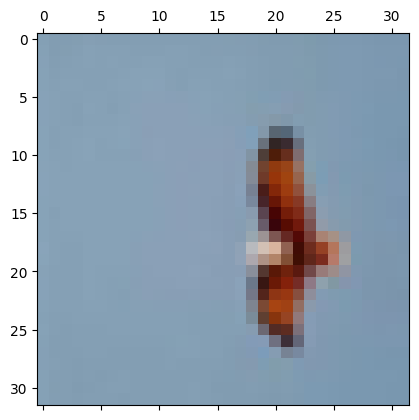

In [36]:
import matplotlib.pyplot as plt
plt.matshow(X_train[1009])

In [35]:
y_train[1009]

array([2], dtype=uint8)

In [10]:
# doing image normalization

X_train=X_train/255.0
X_test=X_test/255.0

X_train.shape

(50000, 32, 32, 3)

In [ ]:
# # flattening the image

# X_train_flatten=X_train.reshape(len(X_train),32*32*3)
# X_train_flatten.shape
# X_test_flatten=X_test.reshape(len(X_test),32*32*3)
# X_test_flatten.shape

# no need of flattening here hence we are doing flattening in the model itself

# import matplotlib.pyplot as plt



array([[[0.00090734, 0.00095348, 0.00096886],
        [0.00066128, 0.00070742, 0.00069204],
        [0.00076894, 0.00073818, 0.00066128],
        ...,
        [0.00242983, 0.00202999, 0.0016609 ],
        [0.00233756, 0.00192234, 0.00156863],
        [0.00227605, 0.00190696, 0.00158401]],

       [[0.00024606, 0.00030757, 0.00030757],
        [0.        , 0.        , 0.        ],
        [0.00027682, 0.00012303, 0.        ],
        ...,
        [0.00189158, 0.00135333, 0.00084583],
        [0.00183007, 0.00127643, 0.00076894],
        [0.0018762 , 0.00133795, 0.00087659]],

       [[0.00038447, 0.00036909, 0.00032295],
        [0.00024606, 0.00010765, 0.        ],
        [0.00075356, 0.00041522, 0.00012303],
        ...,
        [0.00181469, 0.00129181, 0.00076894],
        [0.00184544, 0.00129181, 0.00076894],
        [0.00167628, 0.00112265, 0.00064591]],

       ...,

       [[0.00319877, 0.00261438, 0.00147636],
        [0.00309112, 0.00235294, 0.00052288],
        [0.00304498, 0

In [63]:
with tf.device('/GPU:0'):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),

        tf.keras.layers.Dense(10, activation='softmax')
    ])

In [74]:
model.compile(optimizer='ADAM',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
len(X_train)

50000

In [65]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.4151 - loss: 1.8532
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.5517 - loss: 1.2665
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.6076 - loss: 1.1185
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6445 - loss: 1.0212
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.6743 - loss: 0.9336
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7023 - loss: 0.8568
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 16ms/step - accuracy: 0.7252 - loss: 0.7884
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7506 - loss: 0.7206
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.7687 - loss: 0.6656
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.7880 - loss: 0.6096


In [68]:
model.predict(X_test[1008].reshape(1,32,32,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


array([[0.05486082, 0.35325372, 0.00666802, 0.03465391, 0.00474995,
        0.00180132, 0.00374915, 0.00519   , 0.0820487 , 0.45302433]],
      dtype=float32)

In [5]:
y_test[1008]


array([9], dtype=uint8)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6632 - loss: 1.1356
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


<Axes: >

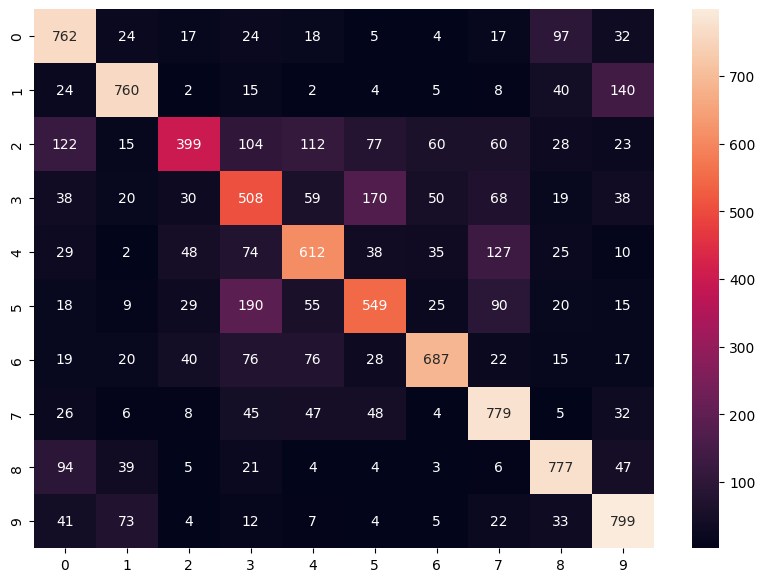

In [73]:
# metrics of this 

import seaborn as sns
model.evaluate(X_test,y_test)

from sklearn.metrics import confusion_matrix
import numpy as np

y_pred=model.predict(X_test)
y_pred_classes=[np.argmax(element) for element in y_pred]
cm=confusion_matrix(y_test,y_pred_classes) 
cm

plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt='d')
# complete this 
